# California Housing Investment Analysis

## Data Science Programming Languages and Tools

**Team Leader:** [DS First project RBS]  
**Group Members:**  
- Hamza NORCHA
- [INSERT NAME]
- [INSERT NAME]
- [INSERT NAME]
- [INSERT NAME]

### Objective
This project analyzes the California Housing dataset to identify areas that may be interesting for different types of real-estate investors. The analysis covers data understanding, exploratory analysis, client-specific investment criteria, feature engineering, predictive modeling, model interpretation, value screening, error analysis, and critical discussion.

> **Important:** Model results and candidate areas are generated by the notebook from the dataset and should not be treated as direct investment advice.


# Part 1 — Data loading and understanding

Each observation in the California Housing dataset represents a **census block group**, not an individual property. The target `MedHouseVal` represents the median house value for that block group, expressed in units of **$100,000**.

Variables that can be useful for investment-related screening include median income, average rooms, average occupancy, house age, population, latitude, and longitude.

Important real-estate variables missing from the dataset include property size, bathrooms, rental prices, historical price appreciation, mortgage rates, property taxes, crime, school quality, vacancy, and individual property condition.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())


Dataset shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Answers

1. **Unit of observation:** a California census block group.
2. **Individual property?** No. Each row is an aggregated geographic area.
3. **Target:** median house value of the block group.
4. **Target unit:** hundreds of thousands of US dollars.
5. **Useful variables:** `MedInc`, `AveRooms`, `AveOccup`, `HouseAge`, `Population`, `Latitude`, and `Longitude`.
6. **Missing variables:** property size, bathrooms, rent, historical prices, taxes, financing costs, crime, schools, vacancy, and property condition.


# Part 2 — Initial data inspection

In [11]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))

print("\nDescriptive statistics:")
display(df.describe().T)


Shape: (20640, 9)

Data types:


,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64



Missing values:


,missing
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


,min,max
MedInc,0.499900,15.000100
HouseAge,1.000000,52.000000
AveRooms,0.846154,141.909091
AveBedrms,0.333333,34.066667
Population,3.000000,35682.000000
AveOccup,0.692308,1243.333333
Latitude,32.540000,41.950000
Longitude,-124.350000,-114.310000
MedHouseVal,0.149990,5.000010


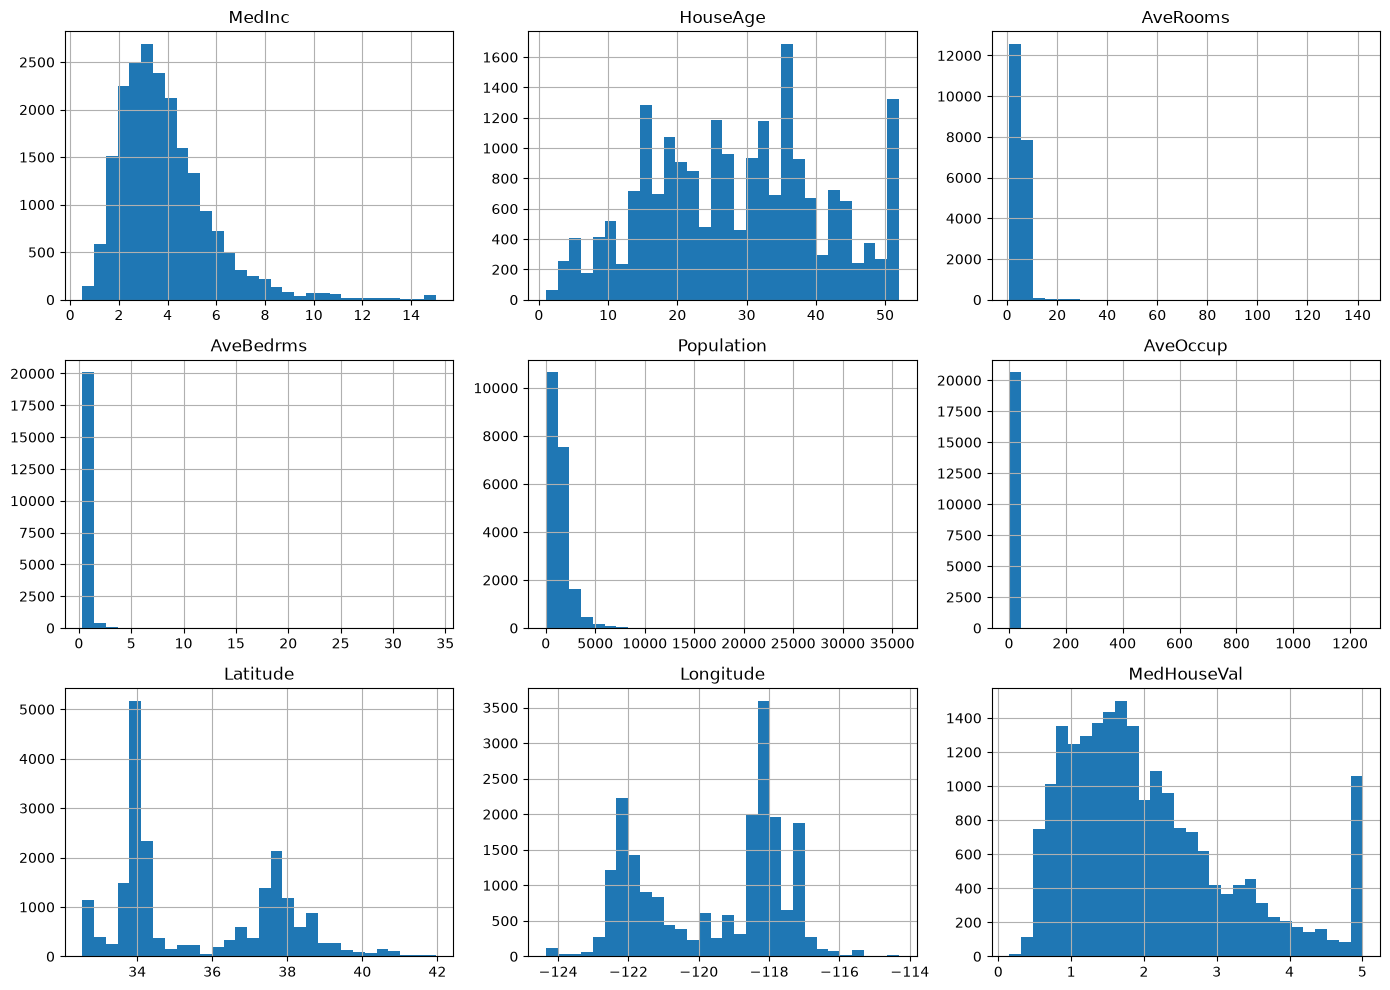

In [12]:
# Identify minimum and maximum values
extremes = pd.DataFrame({
    "min": df.min(),
    "max": df.max()
})
display(extremes)

# Histograms
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


### Interpretation

The dataset contains 20,640 observations and no missing values. Several variables show skewed distributions and some observations are extreme, especially variables such as average rooms, average bedrooms, population, and average occupancy.

The target has an important limitation: median house value is capped at an upper level in this dataset. This can make very expensive areas harder to distinguish and can affect model errors for high-value observations.


# Part 3 — Exploratory Data Analysis

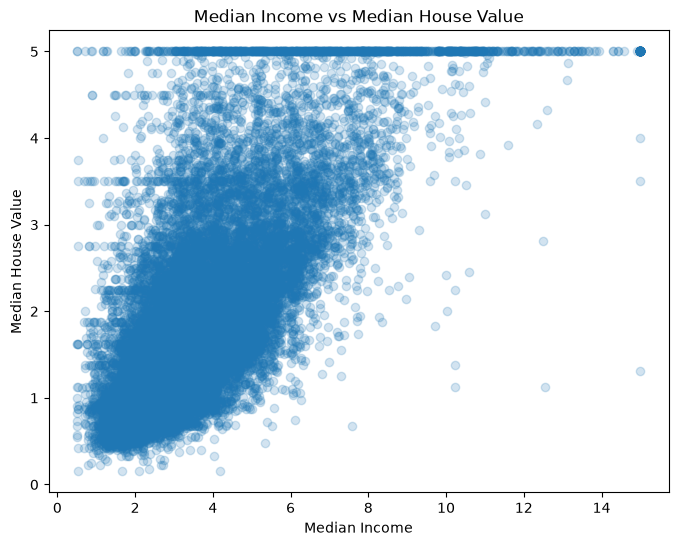

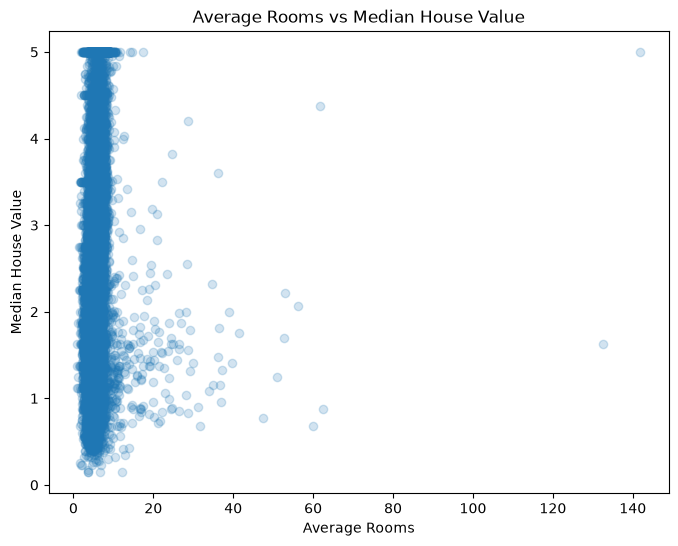

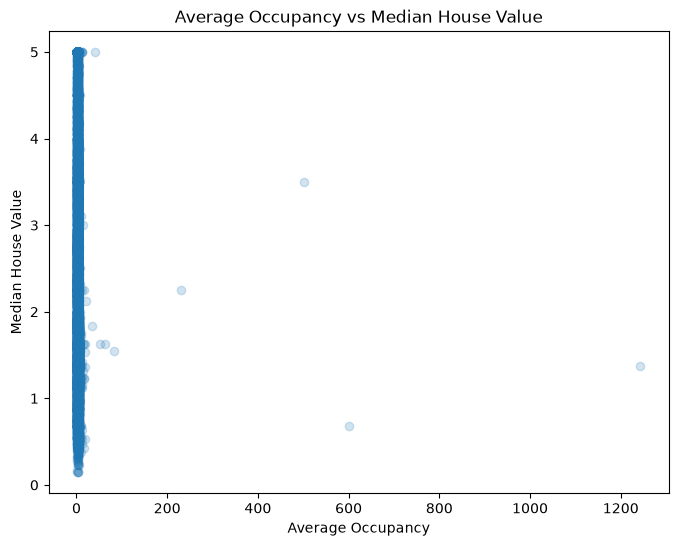

In [13]:
# 1. Median income vs house value
plt.figure(figsize=(8, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

# 2. Average rooms vs house value
plt.figure(figsize=(8, 6))
plt.scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title("Average Rooms vs Median House Value")
plt.show()

# 3. Average occupancy vs house value
plt.figure(figsize=(8, 6))
plt.scatter(df["AveOccup"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Average Occupancy")
plt.ylabel("Median House Value")
plt.title("Average Occupancy vs Median House Value")
plt.show()


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

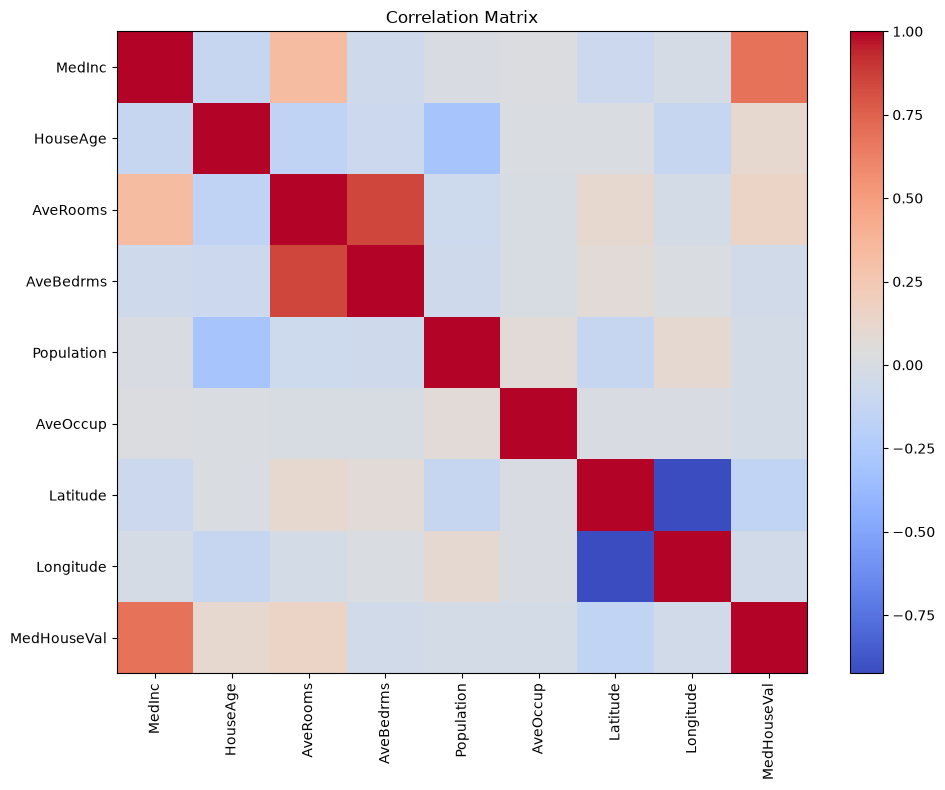

In [14]:
# Correlation analysis
correlation = df.corr(numeric_only=True)
display(correlation["MedHouseVal"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


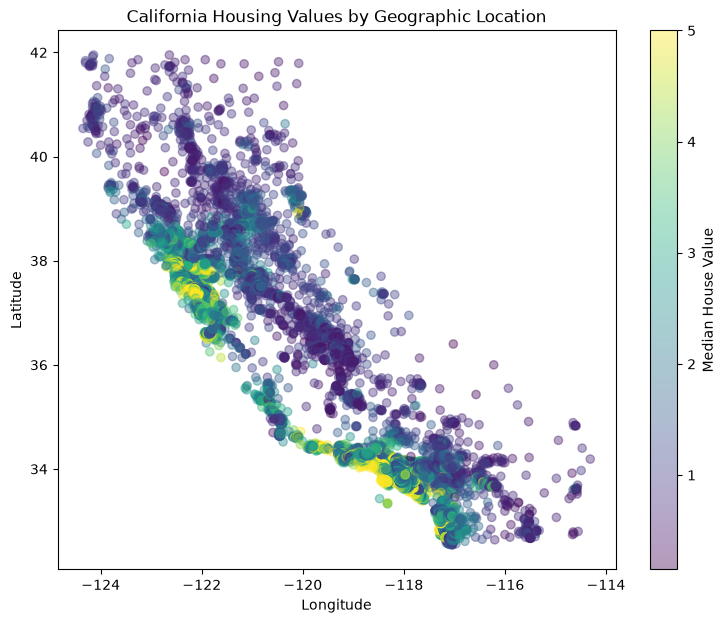

In [15]:
# Geographic visualization
plt.figure(figsize=(9, 7))
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    alpha=0.4
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Values by Geographic Location")
plt.colorbar(label="Median House Value")
plt.show()


### Interpretation

`MedInc` is expected to have the strongest positive association with median house value. Not all relationships are linear; some contain nonlinear patterns and geographic clusters.

Latitude and longitude provide location information. Even when their simple correlations are moderate, geographic variables can capture spatial effects such as proximity to desirable locations, the coast, major cities, and employment centers.

The relationship between median income and house value deserves deeper investigation because it is strong but not perfectly linear.


# Part 4 — Investment clients

For Clients A, B, and C, percentile ranks are used to create comparable scores. A weighted ranking is preferable to arbitrary hard thresholds because it preserves more observations and makes the priorities explicit.


## Client A — Budget-Oriented Investor

**Objective:** relatively low house value, higher local income, and lower occupancy.

**Weights:**
- Price: 45% — minimize
- Income: 40% — maximize
- Occupancy: 15% — minimize


In [16]:
client_a = df.copy()

client_a["PriceScore"] = 1 - client_a["MedHouseVal"].rank(pct=True)
client_a["IncomeScore"] = client_a["MedInc"].rank(pct=True)
client_a["OccupancyScore"] = 1 - client_a["AveOccup"].rank(pct=True)

client_a["Score_A"] = (
    0.45 * client_a["PriceScore"] +
    0.40 * client_a["IncomeScore"] +
    0.15 * client_a["OccupancyScore"]
)

top_A = client_a.sort_values("Score_A", ascending=False).head(10)

display(top_A[[
    "Latitude", "Longitude", "MedHouseVal",
    "MedInc", "AveOccup", "Score_A"
]])


,Latitude,Longitude,MedHouseVal,MedInc,AveOccup,Score_A
2774,33.26,-115.80,0.475,5.3374,1.875000,0.921351
19736,40.12,-121.78,1.063,6.1359,2.058824,0.856109
8222,33.76,-118.23,0.875,5.0000,1.812500,0.853441
18501,37.19,-121.59,1.313,15.0001,2.115385,0.851973
20349,34.17,-119.08,1.250,7.3004,2.172414,0.839482
11912,33.96,-117.44,1.125,12.5381,2.777778,0.827642
19677,39.15,-121.63,0.718,5.3946,2.867647,0.822751
3102,35.64,-117.68,0.957,5.2043,2.402730,0.819677
18957,38.25,-122.05,1.054,6.2299,2.657895,0.815511
18211,37.39,-122.06,0.400,3.6875,1.507299,0.814461


**Justification:** Price receives the largest weight because the client is budget-oriented. Income is almost as important because the client wants economically stronger areas. Occupancy is a secondary preference.


## Client B — Premium Market Investor

**Objective:** high median income, high house value, and larger homes.

**Weights:**
- Income: 40% — maximize
- House value: 40% — maximize
- Rooms: 20% — maximize


In [17]:
client_b = df.copy()

client_b["IncomeScore"] = client_b["MedInc"].rank(pct=True)
client_b["PriceScore"] = client_b["MedHouseVal"].rank(pct=True)
client_b["RoomScore"] = client_b["AveRooms"].rank(pct=True)

client_b["Score_B"] = (
    0.40 * client_b["IncomeScore"] +
    0.40 * client_b["PriceScore"] +
    0.20 * client_b["RoomScore"]
)

top_B = client_b.sort_values("Score_B", ascending=False).head(10)

display(top_B[[
    "Latitude", "Longitude", "MedHouseVal",
    "MedInc", "AveRooms", "Score_B"
]])


,Latitude,Longitude,MedHouseVal,MedInc,AveRooms,Score_B
6727,34.12,-118.12,5.00001,15.0001,10.419355,0.988256
8847,34.09,-118.40,5.00001,15.0001,10.370656,0.988207
9811,36.57,-121.94,5.00001,14.4113,11.634686,0.988159
8853,34.07,-118.41,5.00001,15.0001,9.867036,0.987936
17111,37.46,-122.18,5.00001,15.0001,9.802326,0.987897
8852,34.08,-118.42,5.00001,15.0001,9.729839,0.987800
8851,34.09,-118.42,5.00001,15.0001,9.600000,0.987713
17107,37.44,-122.20,5.00001,15.0001,9.425101,0.987636
5247,34.09,-118.44,5.00001,15.0001,9.368263,0.987568
8850,34.09,-118.41,5.00001,15.0001,9.333333,0.987539


**Justification:** Income and house value receive the highest weights because the client wants exposure to strong, expensive markets. Average rooms receives a lower weight because size is an additional preference.


## Client C — Space-Oriented Investor

**Objective:** more rooms, lower occupancy, and reasonable price.

**Weights:**
- Rooms: 45% — maximize
- Occupancy: 35% — minimize
- Price: 20% — minimize


In [18]:
client_c = df.copy()

client_c["RoomScore"] = client_c["AveRooms"].rank(pct=True)
client_c["OccupancyScore"] = 1 - client_c["AveOccup"].rank(pct=True)
client_c["PriceScore"] = 1 - client_c["MedHouseVal"].rank(pct=True)

client_c["Score_C"] = (
    0.45 * client_c["RoomScore"] +
    0.35 * client_c["OccupancyScore"] +
    0.20 * client_c["PriceScore"]
)

top_C = client_c.sort_values("Score_C", ascending=False).head(10)

display(top_C[[
    "Latitude", "Longitude", "MedHouseVal",
    "AveRooms", "AveOccup", "Score_C"
]])


,Latitude,Longitude,MedHouseVal,AveRooms,AveOccup,Score_C
3258,39.42,-122.89,0.735,21.631579,1.368421,0.982674
11849,39.75,-121.00,0.830,28.615385,0.692308,0.978966
1102,40.06,-121.54,0.675,31.777778,1.740741,0.978507
11862,40.27,-121.25,0.675,59.875000,1.750000,0.978433
2778,33.35,-115.73,0.300,8.714286,1.857143,0.974869
13920,34.22,-115.52,0.425,8.571429,1.936508,0.967637
2768,33.38,-115.94,0.588,8.857143,1.952381,0.962556
12447,33.97,-114.49,0.875,62.422222,1.844444,0.960644
2765,32.69,-115.90,0.575,7.666667,1.814815,0.959215
13919,34.20,-115.85,0.410,9.144208,2.104019,0.955073


**Justification:** Rooms receive the highest weight because space is the primary objective. Lower occupancy is also important because it indicates less household crowding. Price receives a lower weight because the client wants a reasonable price rather than necessarily the cheapest area.


# Part 5 — Feature engineering

## Feature 1 — Rooms per occupant

**Formula:** `AveRooms / AveOccup`

**Meaning:** an approximate indicator of available room space relative to household occupancy.

**Limitation:** it is calculated from aggregated census variables and does not represent the actual usable area of an individual property.

## Feature 2 — Bedroom-to-room ratio

**Formula:** `AveBedrms / AveRooms`

**Meaning:** proportion of average rooms that are bedrooms.

**Limitation:** it does not capture bathrooms, floor area, property condition, or layout quality.


In [19]:
df["RoomsPerOccupant"] = df["AveRooms"] / df["AveOccup"]
df["BedroomRatio"] = df["AveBedrms"] / df["AveRooms"]

display(df[[
    "AveRooms", "AveOccup", "RoomsPerOccupant",
    "AveBedrms", "BedroomRatio"
]].head())


,AveRooms,AveOccup,RoomsPerOccupant,AveBedrms,BedroomRatio
0,6.984127,2.555556,2.732919,1.023810,0.146591
1,6.238137,2.109842,2.956685,0.971880,0.155797
2,8.288136,2.802260,2.957661,1.073446,0.129516
3,5.817352,2.547945,2.283154,1.073059,0.184458
4,6.281853,2.181467,2.879646,1.081081,0.172096


# Part 6 — Predictive modeling

A 80/20 train-test split is used. The baseline predicts the mean training target. Four models are evaluated using MAE, RMSE, and R².


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Use the engineered features as predictors
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Baseline
baseline_pred = np.full(len(y_test), y_train.mean())

models = {
    "Baseline": None,
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

predictions = {"Baseline": baseline_pred}
results = []

results.append({
    "Model": "Baseline",
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
    "R2": r2_score(y_test, baseline_pred)
})

for name, model in list(models.items())[1:]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)


,Model,MAE,RMSE,R2
3,Random Forest,0.333476,0.509529,0.801879
2,Decision Tree,0.434541,0.646857,0.680693
1,Linear Regression,0.486164,0.675347,0.651945
0,Baseline,0.906069,1.144856,-0.000219


### Answers

**1. Why is a baseline necessary?**  
It provides a reference point and shows whether the predictive models add useful information.

**2. Which model performs best?**  
Use the generated `results_df`. The preferred model has lower MAE/RMSE and higher R². In a typical California Housing analysis, Random Forest is expected to outperform the simple linear model.

**3. Does the best predictive model necessarily provide the best explanation?**  
No. A complex model may predict better but be harder to interpret.

**4. Which metric is most useful?**  
MAE is particularly useful for business communication because it expresses the average error directly in the target's units.


# Part 7 — Model interpretation

Random Forest feature importance is used as a simple interpretation method.


,Feature,Importance
0,MedInc,0.532857
5,AveOccup,0.128718
6,Latitude,0.083223
7,Longitude,0.083080
1,HouseAge,0.050783
9,BedroomRatio,0.027722
4,Population,0.024586
8,RoomsPerOccupant,0.024525
2,AveRooms,0.024057
3,AveBedrms,0.020448


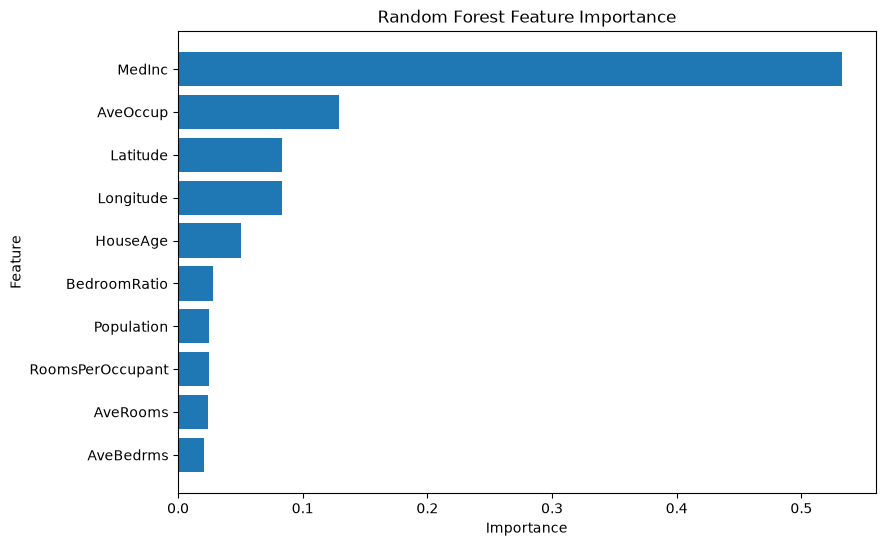

In [21]:
rf_model = models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(9, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()


### Interpretation

Median income and geographic variables are expected to be among the most influential predictors. This is broadly consistent with the EDA.

Feature importance is not causal evidence. A feature can be useful for prediction without causing the target to change.

**Potentially misleading interpretation:** saying that a highly important variable "causes" higher house prices. The model identifies predictive relationships, not causal effects.


# Part 8 — Client D — Model-based value screening

A positive `PredictionGap` means the model predicts a higher value than the observed value. These observations can be screened for further investigation, but the gap is not proof of undervaluation.


In [22]:
# Generate predictions for all observations using the best model
best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Baseline":
    all_predictions = np.full(len(df), y_train.mean())
else:
    best_model = models[best_model_name]
    all_predictions = best_model.predict(X)

df["PredictedValue"] = all_predictions
df["PredictionGap"] = df["PredictedValue"] - df["MedHouseVal"]

# Rank by positive prediction gap
client_d = df.sort_values("PredictionGap", ascending=False).copy()

display(client_d[[
    "Latitude", "Longitude", "MedHouseVal",
    "PredictedValue", "PredictionGap", "MedInc", "AveOccup"
]].head(20))


,Latitude,Longitude,MedHouseVal,PredictedValue,PredictionGap,MedInc,AveOccup
5887,34.15,-118.33,0.17500,3.073271,2.898271,2.3667,1.876812
4548,34.02,-118.21,0.67500,3.385591,2.710591,7.5752,7.857143
20349,34.17,-119.08,1.25000,3.898034,2.648034,7.3004,2.172414
2277,36.81,-119.79,1.32200,3.933076,2.611076,4.2500,1.944882
2214,36.84,-119.85,2.13900,4.517184,2.378184,8.9669,2.754098
2041,36.73,-119.69,1.71700,4.089951,2.372951,7.2211,2.644737
2250,36.80,-119.80,1.69300,4.057017,2.364017,6.3359,2.353896
9188,34.24,-117.86,0.14999,2.504991,2.355001,4.1932,2.791111
16304,38.01,-121.37,2.42000,4.713000,2.293000,10.0088,3.235669
2225,36.81,-119.84,1.88300,3.836779,1.953779,7.7062,2.574176


In [23]:
# Additional business filter:
# income at or above median and occupancy at or below the 75th percentile

income_threshold = df["MedInc"].median()
occupancy_threshold = df["AveOccup"].quantile(0.75)

candidates_D = client_d[
    (client_d["PredictionGap"] > 0) &
    (client_d["MedInc"] >= income_threshold) &
    (client_d["AveOccup"] <= occupancy_threshold)
].copy()

top_D = candidates_D.head(10)

display(top_D[[
    "Latitude", "Longitude", "MedHouseVal",
    "PredictedValue", "PredictionGap",
    "MedInc", "AveOccup"
]])


,Latitude,Longitude,MedHouseVal,PredictedValue,PredictionGap,MedInc,AveOccup
20349,34.17,-119.08,1.25000,3.898034,2.648034,7.3004,2.172414
2277,36.81,-119.79,1.32200,3.933076,2.611076,4.2500,1.944882
2214,36.84,-119.85,2.13900,4.517184,2.378184,8.9669,2.754098
2041,36.73,-119.69,1.71700,4.089951,2.372951,7.2211,2.644737
2250,36.80,-119.80,1.69300,4.057017,2.364017,6.3359,2.353896
9188,34.24,-117.86,0.14999,2.504991,2.355001,4.1932,2.791111
16304,38.01,-121.37,2.42000,4.713000,2.293000,10.0088,3.235669
2225,36.81,-119.84,1.88300,3.836779,1.953779,7.7062,2.574176
13952,34.22,-117.15,1.71900,3.621288,1.902288,7.2371,2.908257
14657,32.78,-117.15,2.05100,3.785819,1.734819,5.2500,2.151408


### Answers

1. A large positive prediction gap is not proof of undervaluation because the model can be wrong.
2. The gap can result from missing variables, unusual local conditions, data quality issues, model limitations, or target capping.
3. Before investing, additional data should include rental prices, historical prices, taxes, mortgage rates, crime, schools, property size, vacancy, employment, and accessibility.


# Part 9 — Error analysis

Best non-baseline model: Random Forest

Largest absolute errors:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerOccupant,BedroomRatio,Observed,Predicted,Error,AbsoluteError
6688,0.4999,28.0,7.677419,1.870968,142.0,4.580645,34.15,-118.08,1.676056,0.243697,5.00001,1.947859,-3.052151,3.052151
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,1.903475,0.340771,0.17500,3.073271,2.898271,2.898271
12389,3.7727,24.0,10.953586,1.848101,473.0,1.995781,33.75,-116.43,5.488372,0.168721,5.00001,2.109295,-2.890715,2.890715
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,2.045455,0.177778,4.50000,1.619478,-2.880522,2.880522
12069,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,2.201754,0.151394,5.00001,2.144717,-2.855293,2.855293
17306,2.7275,17.0,5.574286,1.051429,681.0,1.945714,34.38,-119.55,2.864905,0.188621,5.00001,2.185576,-2.814434,2.814434
4548,7.5752,52.0,3.142857,1.000000,55.0,7.857143,34.02,-118.21,0.400000,0.318182,0.67500,3.385591,2.710591,2.710591
15238,4.2875,30.0,8.119205,1.357616,380.0,2.516556,32.96,-117.30,3.226316,0.167210,5.00001,2.324843,-2.675167,2.675167
12220,5.2066,4.0,10.500000,1.445652,311.0,3.380435,33.51,-117.32,3.106109,0.137681,5.00001,2.328603,-2.671407,2.671407
20349,7.3004,32.0,5.724138,0.758621,63.0,2.172414,34.17,-119.08,2.634921,0.132530,1.25000,3.898034,2.648034,2.648034



Errors by price group:


,MAE,MeanError,Count
PriceGroup,,,
Higher-value,0.424739,-0.150844,2050
Lower-value,0.243442,0.169404,2078


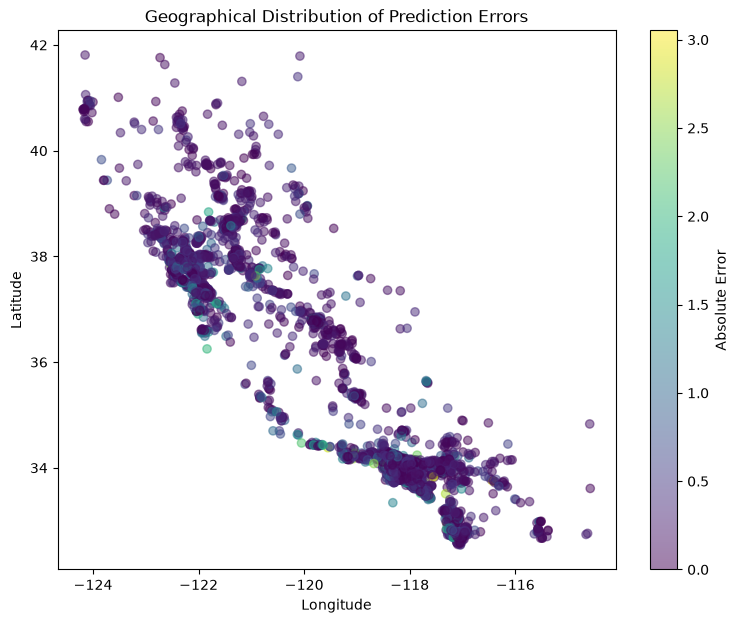

In [24]:
# Use the best non-baseline model
model_name = results_df[results_df["Model"] != "Baseline"].iloc[0]["Model"]
best_pred = predictions[model_name]

error_df = X_test.copy()
error_df["Observed"] = y_test.values
error_df["Predicted"] = best_pred
error_df["Error"] = error_df["Predicted"] - error_df["Observed"]
error_df["AbsoluteError"] = error_df["Error"].abs()

print("Best non-baseline model:", model_name)

print("\nLargest absolute errors:")
display(error_df.sort_values("AbsoluteError", ascending=False).head(20))

median_target = y_train.median()
error_df["PriceGroup"] = np.where(
    error_df["Observed"] < median_target,
    "Lower-value",
    "Higher-value"
)

print("\nErrors by price group:")
display(error_df.groupby("PriceGroup").agg(
    MAE=("AbsoluteError", "mean"),
    MeanError=("Error", "mean"),
    Count=("Error", "size")
))

plt.figure(figsize=(9, 7))
plt.scatter(
    error_df["Longitude"],
    error_df["Latitude"],
    c=error_df["AbsoluteError"],
    alpha=0.5
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Prediction Errors")
plt.colorbar(label="Absolute Error")
plt.show()


### Interpretation

The table and geographic plot should be used to determine whether errors are concentrated in particular regions. Comparing lower-value and higher-value groups helps identify whether the model behaves differently across the price distribution.

The target cap can contribute to larger errors for high-value areas. In practice, this means the model should be used as a screening tool rather than as an automatic investment decision system.


# Part 10 — Final investment recommendations

The following cells automatically display the top five candidate areas for each client. Latitude and longitude are used because the assignment does not require city names.


In [25]:
print("CLIENT A — TOP 5")
display(top_A[[
    "Latitude", "Longitude", "MedHouseVal",
    "MedInc", "AveOccup", "Score_A"
]].head(5))

print("CLIENT B — TOP 5")
display(top_B[[
    "Latitude", "Longitude", "MedHouseVal",
    "MedInc", "AveRooms", "Score_B"
]].head(5))

print("CLIENT C — TOP 5")
display(top_C[[
    "Latitude", "Longitude", "MedHouseVal",
    "AveRooms", "AveOccup", "Score_C"
]].head(5))

print("CLIENT D — TOP 5")
display(top_D[[
    "Latitude", "Longitude", "MedHouseVal",
    "PredictedValue", "PredictionGap",
    "MedInc", "AveOccup"
]].head(5))


CLIENT A — TOP 5


,Latitude,Longitude,MedHouseVal,MedInc,AveOccup,Score_A
2774,33.26,-115.80,0.475,5.3374,1.875000,0.921351
19736,40.12,-121.78,1.063,6.1359,2.058824,0.856109
8222,33.76,-118.23,0.875,5.0000,1.812500,0.853441
18501,37.19,-121.59,1.313,15.0001,2.115385,0.851973
20349,34.17,-119.08,1.250,7.3004,2.172414,0.839482


CLIENT B — TOP 5


,Latitude,Longitude,MedHouseVal,MedInc,AveRooms,Score_B
6727,34.12,-118.12,5.00001,15.0001,10.419355,0.988256
8847,34.09,-118.40,5.00001,15.0001,10.370656,0.988207
9811,36.57,-121.94,5.00001,14.4113,11.634686,0.988159
8853,34.07,-118.41,5.00001,15.0001,9.867036,0.987936
17111,37.46,-122.18,5.00001,15.0001,9.802326,0.987897


CLIENT C — TOP 5


,Latitude,Longitude,MedHouseVal,AveRooms,AveOccup,Score_C
3258,39.42,-122.89,0.735,21.631579,1.368421,0.982674
11849,39.75,-121.00,0.830,28.615385,0.692308,0.978966
1102,40.06,-121.54,0.675,31.777778,1.740741,0.978507
11862,40.27,-121.25,0.675,59.875000,1.750000,0.978433
2778,33.35,-115.73,0.300,8.714286,1.857143,0.974869


CLIENT D — TOP 5


,Latitude,Longitude,MedHouseVal,PredictedValue,PredictionGap,MedInc,AveOccup
20349,34.17,-119.08,1.250,3.898034,2.648034,7.3004,2.172414
2277,36.81,-119.79,1.322,3.933076,2.611076,4.2500,1.944882
2214,36.84,-119.85,2.139,4.517184,2.378184,8.9669,2.754098
2041,36.73,-119.69,1.717,4.089951,2.372951,7.2211,2.644737
2250,36.80,-119.80,1.693,4.057017,2.364017,6.3359,2.353896


### Recommendation framework

**Client A — Budget-Oriented:** choose the five highest-ranked areas using low value, high income, and low occupancy.  
**Risk:** low price may reflect unobserved negative characteristics.

**Client B — Premium:** choose the five highest-ranked areas using high income, high house value, and more rooms.  
**Risk:** a high current value does not guarantee future appreciation or investment return.

**Client C — Space-Oriented:** choose the five highest-ranked areas using more rooms, lower occupancy, and reasonable value.  
**Risk:** average rooms is an aggregated census measure, not individual property floor area.

**Client D — Value:** choose the five largest positive prediction gaps after the income/occupancy filter.  
**Risk:** a prediction gap can reflect model error or missing variables rather than genuine undervaluation.


# Part 11 — Critical discussion

## Question 1 — Current value vs appreciation vs investment return

Predicting current house value means estimating today's median value from observed characteristics. Predicting future appreciation means estimating how prices may change over time. Predicting investment return is broader and should incorporate appreciation, rental income, financing, taxes, maintenance, vacancy, and transaction costs.

Therefore, current value, future appreciation, and investment return are different objectives.

## Question 2 — Why is the dataset insufficient?

The dataset does not contain many variables needed for a real investment decision, including rental prices, historical prices, mortgage rates, property taxes, crime, school quality, property size, vacancy, maintenance costs, and accessibility.

## Question 3 — Why keep Linear Regression if Random Forest is better?

First, Linear Regression is easier to interpret because coefficients provide a simple description of the relationship between predictors and the target. Second, it is simple and provides a transparent benchmark against more complex models.

## Question 4 — Why does high predicted value not imply good investment?

A high predicted house value only indicates an expected level of current value based on the model. It does not establish future appreciation, rental yield, affordability, risk, financing costs, or expected return.

## Question 5 — How would additional data improve the project?

Rental prices would allow rental-yield analysis. Historical prices would allow appreciation and volatility analysis. Mortgage rates would improve financing and leveraged-return calculations. Property taxes would improve cash-flow estimates. Crime and school data would improve location-risk analysis. Distance from major cities could be used to model accessibility and demand.


# Optional Bonus A — Cross-validation

Five-fold cross-validation is used to compare Linear Regression and Random Forest.


In [26]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for name, model in cv_models.items():
    scores = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    cv_results.append({
        "Model": name,
        "Mean RMSE": scores.mean(),
        "Std RMSE": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
display(cv_results)


,Model,Mean RMSE,Std RMSE
0,Linear Regression,0.680788,0.030265
1,Random Forest,0.508682,0.009510


# Final conclusion

The analysis demonstrates how the California Housing dataset can be used for exploratory analysis, client segmentation, and predictive screening. Median income and geographic information are important predictors of median house value, while nonlinear models can capture relationships that a simple linear model cannot.

However, the dataset is not sufficient for making actual investment decisions. The analysis should therefore be considered a **first-stage screening framework**. Further investment analysis should incorporate rental income, historical price changes, financing costs, taxes, risk indicators, property-level characteristics, and other local market information.
